# House Price Prediction Project

# Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import  statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# import function to perform linear regression
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import KFold, cross_val_score

# import StandardScaler to perform scaling
from sklearn.preprocessing import StandardScaler 

# import SGDRegressor from sklearn to perform linear regression with stochastic gradient descent
from sklearn.linear_model import SGDRegressor


# import function for ridge regression
from sklearn.linear_model import Ridge

# import function for lasso regression
from sklearn.linear_model import Lasso

# import function for elastic net regression
from sklearn.linear_model import ElasticNet

# import function to perform GridSearchCV
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
df = pd.read_csv("02_housing.csv")
df.head()

,CRIM,ZN,INDUS,RIVER,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,NaN,36.2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   RIVER    486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    486 non-null    float64
 12  PRICE    506 non-null    float64
dtypes: float64(11), int64(2)
memory usage: 51.5 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,486.0,3.611874,8.720192,0.00632,0.081900,0.253715,3.560263,88.9762
ZN,486.0,11.211934,23.388876,0.00000,0.000000,0.000000,12.500000,100.0000
INDUS,486.0,11.083992,6.835896,0.46000,5.190000,9.690000,18.100000,27.7400
RIVER,486.0,0.069959,0.255340,0.00000,0.000000,0.000000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.538000,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.208500,6.623500,8.7800
AGE,486.0,68.518519,27.999513,2.90000,45.175000,76.800000,93.975000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.207450,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.000000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.000000,666.000000,711.0000


# Checking for Duplicates

In [5]:
df.duplicated().sum()

np.int64(0)

# Handling Missing Values

In [6]:
# display the total number of null values in each column of dataframe

# 'ascending = False' sorts values in the descending order
Total = df.isnull().sum().sort_values(ascending=False)          

# percentage of missing values
Percent = (df.isnull().sum()*100/df.isnull().count()).sort_values(ascending=False)  

# concat the 'Total' and 'Percent' columns using 'concat' function
# 'keys' is the list of column names
# 'axis = 1' concats along the columns
missing_data = pd.concat([Total, Percent], axis=1, keys=['Total', 'Percent'])    
missing_data

,Total,Percent
CRIM,20,3.952569
ZN,20,3.952569
INDUS,20,3.952569
RIVER,20,3.952569
AGE,20,3.952569
LSTAT,20,3.952569
NOX,0,0.000000
RM,0,0.000000
DIS,0,0.000000
RAD,0,0.000000


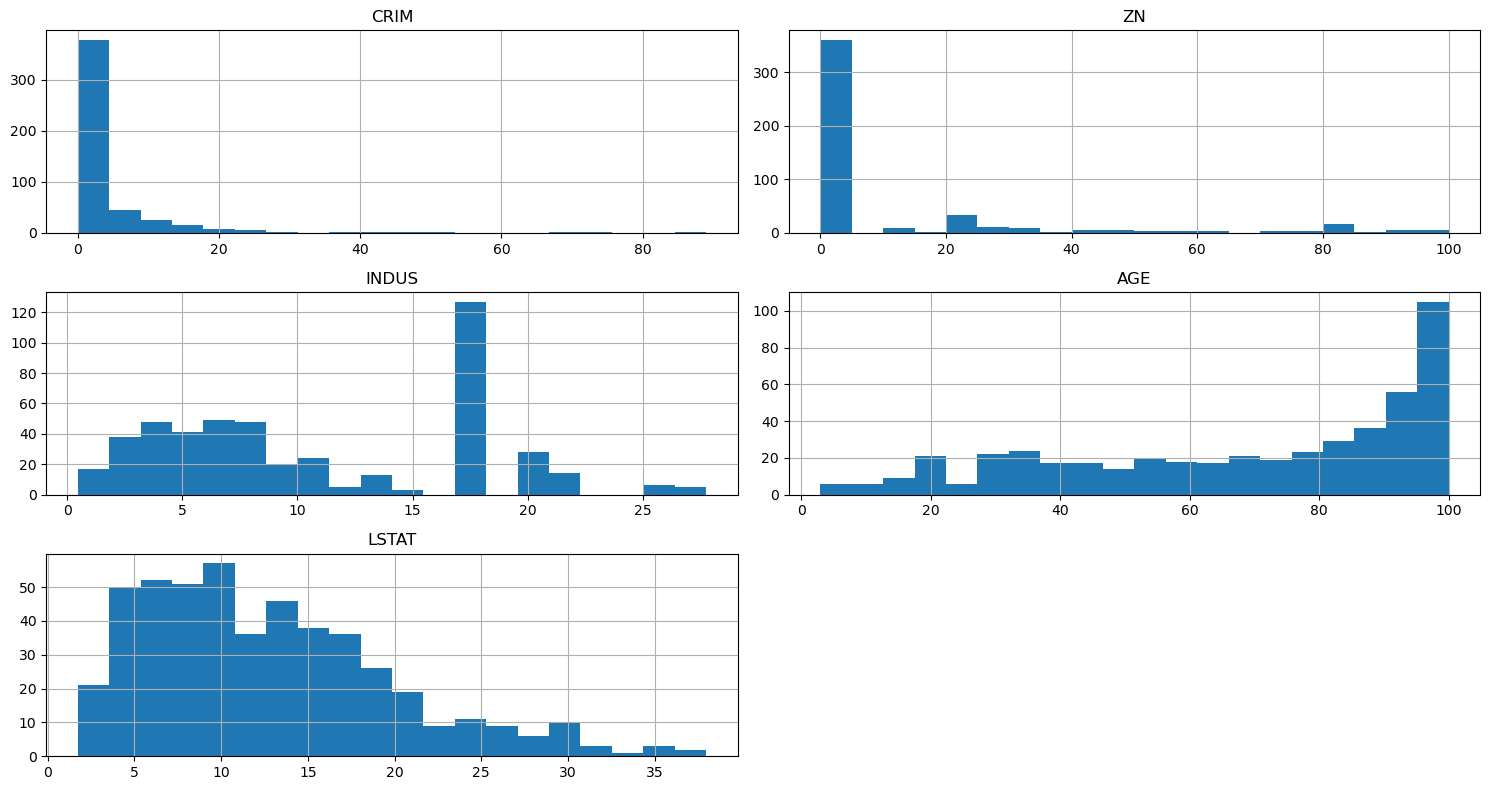

In [7]:
df_missing_values = df[['CRIM','ZN','INDUS','AGE','LSTAT']]
# plot histogram of all variables which have missing values
# set the number of bins to 20
# set the figure size using 'figsize'
df_missing_values.hist(bins = 20, figsize = (15,8))
# adjust the subplots
plt.tight_layout()
# display the plot
plt.show()

In [8]:
df["CRIM"]=df["CRIM"].fillna(df["CRIM"].median())
df["ZN"]=df["ZN"].fillna(df["ZN"].median())
df["INDUS"]=df["INDUS"].fillna(df["INDUS"].median())
df["RIVER"]=df["RIVER"].fillna(df["RIVER"].mode()[0])
df["AGE"]=df["AGE"].fillna(df["AGE"].median())
df["LSTAT"]=df["LSTAT"].fillna(df["LSTAT"].mean())

# Outlier Visualization

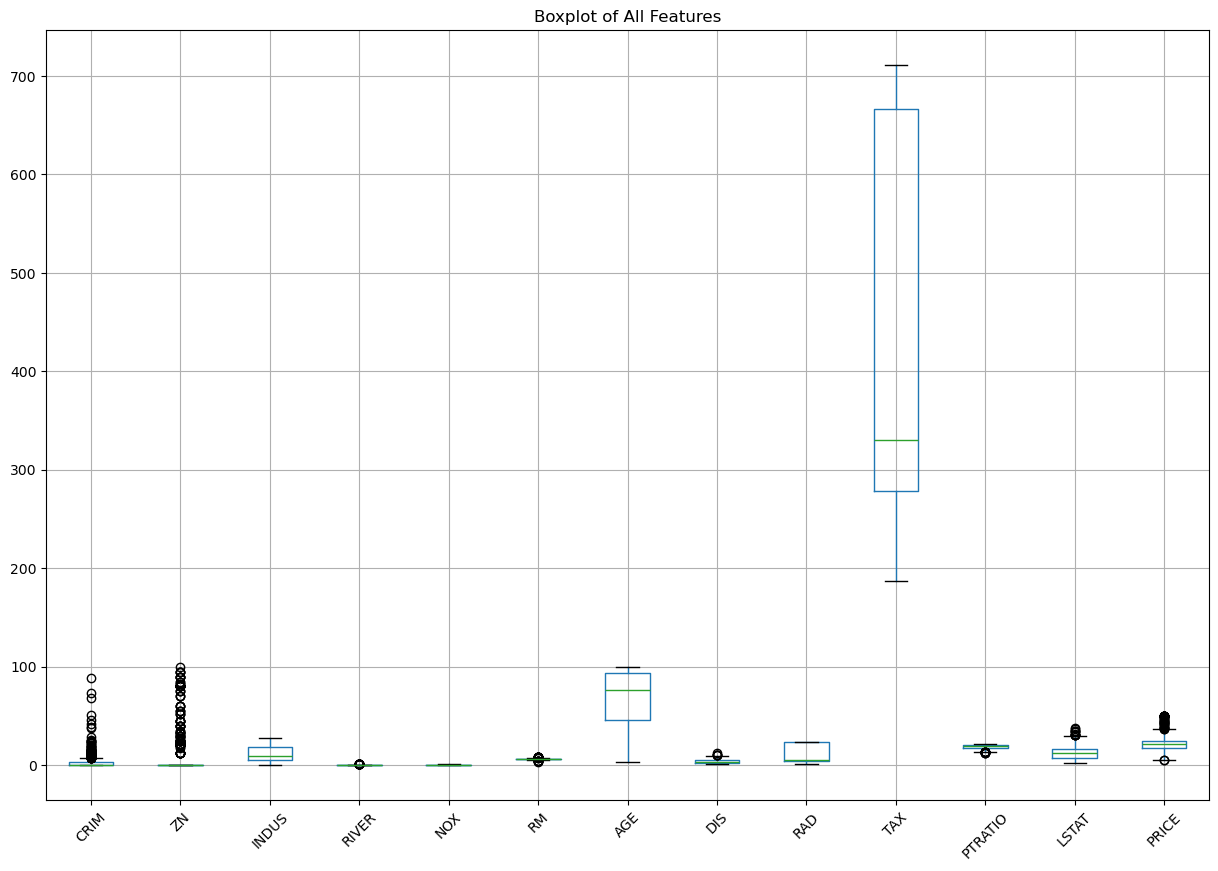

In [9]:
plt.figure(figsize=(15, 10))

df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of All Features")
plt.show()

# Correlation Heatmap

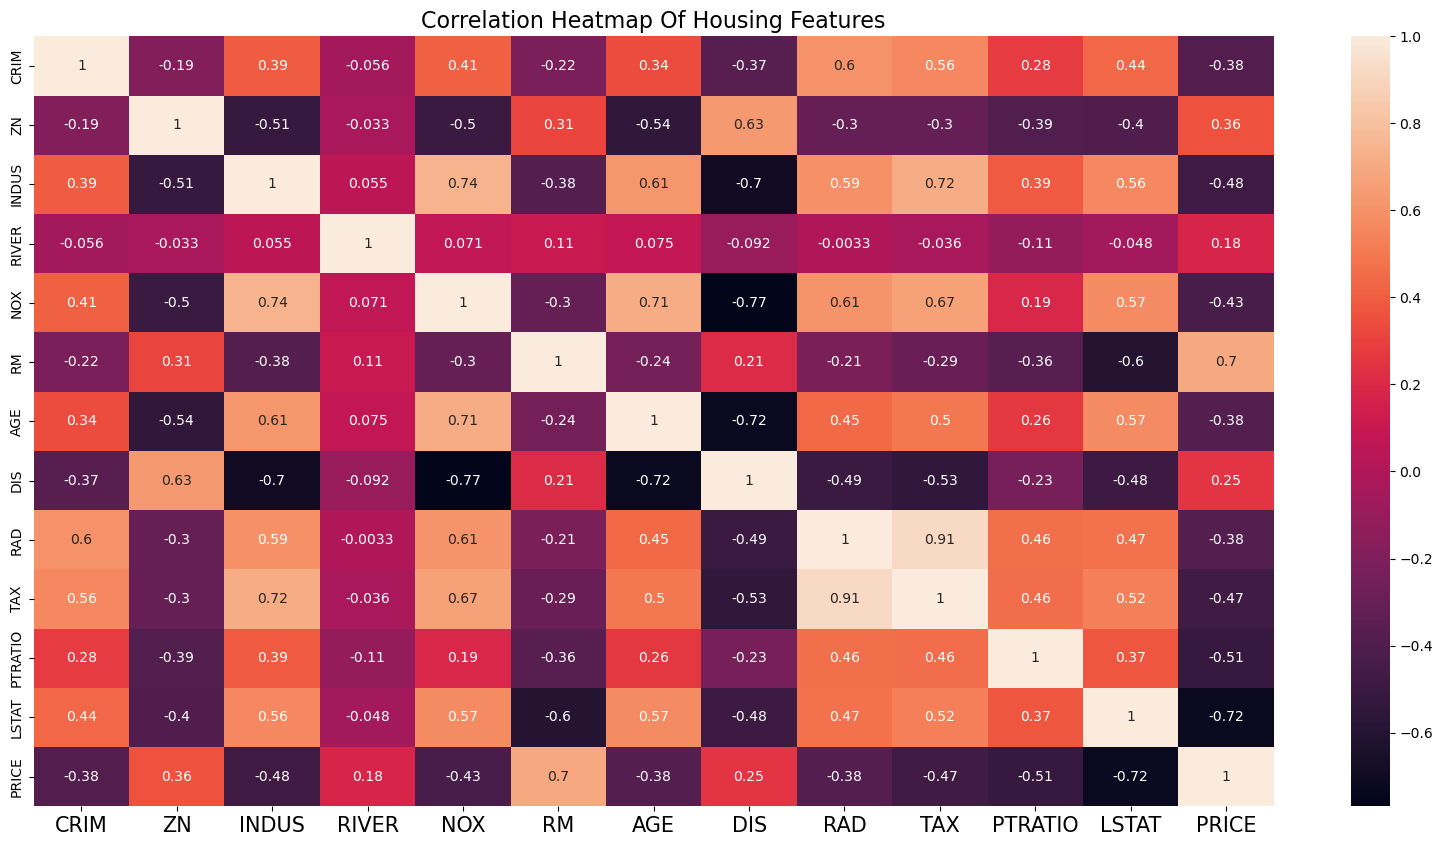

In [10]:
# set dimensions for the plot figure
fig_dims = (20,10)
fig, ax = plt.subplots(figsize=fig_dims)

# plot the heat map
# corr: give the correlation matrix
# annot: prints the correlation values in the chart
# annot_kws: sets the font size of the annotation
sns.heatmap(df.corr(), annot = True, annot_kws = {"size": 10})


# set text size using 'fontsize'
plt.title("Correlation Heatmap Of Housing Features",fontsize = 16)
plt.xticks(rotation = 'horizontal', fontsize = 15)

# display the plot
plt.show()

# Data Type Conversion and Encoding

In [11]:
df["RIVER"]=df["RIVER"].astype("int64")
df["RAD"]=df["RAD"].astype("object")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   RIVER    506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    object 
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  PRICE    506 non-null    float64
dtypes: float64(10), int64(2), object(1)
memory usage: 51.5+ KB


In [12]:
# use 'drop_first' to create (n-1) dummy variables
# use 'prefix' to add prefix to dummy variable
df_encoded = pd.get_dummies(df,columns=['RAD'], drop_first=True, dtype = "int64")

# Selecting Feature and target Variable

In [13]:
X = df_encoded.drop(["PRICE"],axis = 1)
y = df_encoded["PRICE"]

# Train Test Split

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 100)

In [15]:
# to estimate the regression coefficient , a constant term of '1' needs to be added as a separate column
# 'sm.add_constant' adds the intercept to the model
X_train_ols = sm.add_constant(X_train)
X_train_ols = X_train_ols.astype("float")

X_test_ols = sm.add_constant(X_test)
X_test_ols = X_test_ols.astype("float")

# build a model with an intercept
ols_model = sm.OLS(y_train, X_train_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     54.25
Date:                Sun, 31 May 2026   Prob (F-statistic):           3.33e-96
Time:                        21:52:30   Log-Likelihood:                -1198.3
No. Observations:                 404   AIC:                             2437.
Df Residuals:                     384   BIC:                             2517.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.9074      5.992      6.326      0.0

In [16]:
# Level of Errors for full model (using OLS Estiamtion)
# predict the values of target variable using train data
y_train_pred = ols_model.predict(X_train_ols)
mse_train = mean_squared_error(y_train, y_train_pred)
print ("MSE for Train Data:",mse_train)

y_test_pred = ols_model.predict(X_test_ols)
mse_test = mean_squared_error(y_test, y_test_pred)
print ("MSE for Test Data:",mse_test)

MSE for Train Data: 22.069239850579798
MSE for Test Data: 24.90535566206948


# Scaling

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Cross Validation

In [18]:
# 5-Fold Cross Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression

In [19]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

# predict the values of target variable using train data
linear_train_pred = linear_model.predict(X_train_scaled)

linear_test_pred = linear_model.predict(X_test_scaled)

In [20]:
mse_train = mean_squared_error(y_train, linear_train_pred)
print ("MSE for Train Data:",mse_train)

mse_test = mean_squared_error(y_test, linear_test_pred)
print ("MSE for Test Data:",mse_test)

MSE for Train Data: 22.069239850579805
MSE for Test Data: 24.905355662070033


In [21]:
# Model Summary:
print('model intercept :', linear_model.intercept_)
print('model coefficients : ', linear_model.coef_)
print('Model R-square_train : ', r2_score(y_train,linear_train_pred))
print('Model R-square_test : ', r2_score(y_test,linear_test_pred))

model intercept : 22.621039603960394
model coefficients :  [-0.70083711  1.10348487 -0.50365501  0.92277894 -1.84604781  2.51761044
 -0.2883244  -3.1223032  -0.95318533 -1.93302946 -3.40790652  0.23115969
  1.24489408  0.92218356  1.02753119  0.08996491  0.81124873  0.9870642
  2.33852042]
Model R-square_train :  0.7285693624051284
Model R-square_test :  0.7421654496157477


In [22]:
# obtain the R-squared
r_square = linear_model.score(X_train_scaled, y_train)

# print the R-squared 
print("The R-squared value is", r_square)

The R-squared value is 0.7285693624051284


# Gradient Descent + GridSearchCV

In [23]:
# Full model using Full batch Gradient Descent (Hyper parameter tunning):

# Instantiate the SGDRegressor

sgd = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None,learning_rate='constant', random_state=42)

#Define the parameter grid, eta0 is the learning rate in Learning rate in scikit-learn implementation

param_grid = {'eta0': np.linspace(0.001, 1,1000)}

#Grid Search
sgd_grid = GridSearchCV(estimator=sgd,param_grid=param_grid,scoring='neg_mean_squared_error',cv=kf,n_jobs=-1)

#Fit grid search
sgd_grid.fit(X_train_scaled, y_train)

#Show best params
print("Best parameters found:", sgd_grid.best_params_)

# Evaluate on test set
sgd_best_model = sgd_grid.best_estimator_

Best parameters found: {'eta0': np.float64(0.001)}


In [24]:
# Full model using Stochastic Gradient Descent

# Make predictions on your train data
sgd_train_pred = sgd_best_model.predict(X_train_scaled)

mse_train = mean_squared_error(y_train, sgd_train_pred)
print ("MSE for Train Data:",mse_train)

# Make predictions on your test data
sgd_test_pred = sgd_best_model.predict(X_test_scaled)

mse_test = mean_squared_error(y_test, sgd_test_pred)
print ("MSE for Test Data:",mse_test)

MSE for Train Data: 22.15379234550941
MSE for Test Data: 25.11616288261991


In [25]:
# obtain the R-squared
r_square = sgd_best_model.score(X_train_scaled, y_train)

# print the R-squared 
print("The R-squared value is", r_square)

The R-squared value is 0.7275294472216257


# Ridge Regression + GridSearchCV

In [26]:
# 'alpha' assigns the regularization strength to the model
tuned_paramaters = [{'alpha':np.linspace(0.001,1,1000)}]
 
# instantiate the Ridge() method
ridge = Ridge()

# use GridSearchCV() to find the optimal value of alpha
# estimator: pass the ridge regression model
# param_grid: pass the list 'tuned_parameters'

ridge_grid = GridSearchCV(estimator = ridge, 
                          param_grid = tuned_paramaters, 
                          cv = kf, scoring = 'neg_mean_squared_error',n_jobs = -1)

# fit the model on X_train_scaled and y_train using fit()
ridge_grid.fit(X_train_scaled, y_train) # best model selected

# get the best parameters
print('Best parameters for Ridge Regression:', ridge_grid.best_params_)

ridge_best_model = ridge_grid.best_estimator_

Best parameters for Ridge Regression: {'alpha': np.float64(1.0)}


In [27]:
# For training set:
# ridge_train_pred: prediction made by the model on the training dataset 'X_train_scaled'
# y_train: actual values ofthe target variable for the train dataset
 
# predict the output of the target variable from the train data 
ridge_train_pred = ridge_best_model.predict(X_train_scaled)

# calculate the MSE using the "mean_squared_error" function
# MSE for the train data
mse_train = mean_squared_error(y_train, ridge_train_pred)

# print the MSE for the train set
print("MSE for Train Data: ", mse_train)
    
# For testing set:
# ridge_test_pred: prediction made by the model on the test dataset 'X_test_scaled'
# y_test: actual values of the target variable for the test dataset
 
# predict the output of the target variable from the test data
ridge_test_pred = ridge_best_model.predict(X_test_scaled)

# MSE for the test data
mse_test = mean_squared_error(y_test, ridge_test_pred)

# print the MSE for the test set
print("MSE for Test Data:", mse_test)

MSE for Train Data:  22.071227063859315
MSE for Test Data: 24.9475298999817


In [28]:
ridge_best_model.coef_

array([-0.69250441,  1.08904001, -0.51218237,  0.92549118, -1.81737518,
        2.52399691, -0.29569212, -3.09612486, -0.90327811, -1.9215274 ,
       -3.39649956,  0.20366805,  1.20176932,  0.84480695,  0.95275425,
        0.04750391,  0.77577309,  0.94763337,  2.19915745])

In [29]:
# obtain the R-squared
r_square_ridge = ridge_best_model.score(X_train_scaled, y_train)

# print the R-squared 
print("The R-squared value is", r_square_ridge)

The R-squared value is 0.7285449215738562


# Lasso Regression + GridSearchCV

In [30]:
# 'alpha' assigns the regularization strength to the model
tuned_paramaters = [{'alpha':np.linspace(0.001,1,1000)}]
 
# instantiate the Lasso() method
lasso = Lasso()

# use GridSearchCV() to find the optimal value of alpha
# estimator: pass the lasso regression model
# param_grid: pass the list 'tuned_parameters'
# cv: number of folds in k-fold 
lasso_grid = GridSearchCV(estimator = lasso, 
                          param_grid = tuned_paramaters, 
                          cv = kf, scoring = 'neg_mean_squared_error',n_jobs = -1 )

# fit the model on X_train_scaled and y_train using fit()
lasso_grid.fit(X_train_scaled, y_train)

# get the best parameters
print('Best parameters for Lasso Regression:', lasso_grid.best_params_)

lasso_best_model = lasso_grid.best_estimator_

Best parameters for Lasso Regression: {'alpha': np.float64(0.134)}


In [31]:
# For training set:
# lasso_train_pred: prediction made by the model on the training dataset 'X_train_scaled'
# y_train: actual values ofthe target variable for the train dataset
 
# predict the output of the target variable from the train data 
lasso_train_pred = lasso_best_model.predict(X_train_scaled)

# calculate the MSE using the "mean_squared_error" function
# MSE for the train data
mse_train = mean_squared_error(y_train, lasso_train_pred)

# print the MSE for the train set
print("MSE for Train Data:", mse_train)
    
# For testing set:
# lasso_test_pred: prediction made by the model on the test dataset 'X_test'
# y_test: actual values of the target variable for the test dataset
 
# predict the output of the target variable from the test data
lasso_test_pred = lasso_best_model.predict(X_test_scaled)

# MSE for the test data
mse_test = mean_squared_error(y_test, lasso_test_pred)

# print the MSE for the test set
print("MSE for Test Data:", mse_test)

MSE for Train Data: 22.89511362906347
MSE for Test Data: 26.44132854123872


In [32]:
# create a dataframe to store the variable names and their corresponding coefficient values
# pass the dictionary as data to the dataframe
# 'coef_' returns the value of each coefficient
df_lasso_coeff = pd.DataFrame(data = {'Variable': X.columns, 'Coefficient': lasso_best_model.coef_})

# print the variables having the coefficient equal to zero
# 'to_list()' converts the output to the list type
print('Insignificant variables obtained from Lasso Regression when alpha is tuned:',
      df_lasso_coeff.Variable[df_lasso_coeff.Coefficient == 0].to_list())

Insignificant variables obtained from Lasso Regression when alpha is tuned: ['TAX', 'RAD_2', 'RAD_4', 'RAD_5', 'RAD_24']


In [33]:
lasso_best_model.coef_

array([-0.28030439,  0.68963545, -0.46939194,  0.89484511, -1.22279741,
        2.69436908, -0.10866228, -2.192802  , -0.        , -1.74827562,
       -3.48426086, -0.        ,  0.66355152, -0.        ,  0.        ,
       -0.32053194,  0.21390175,  0.3379501 ,  0.        ])

In [34]:
# obtain the R-squared
r_square_lasso = lasso_best_model.score(X_train_scaled, y_train)

# print the R-squared 
print("The R-squared value is", r_square_lasso)

The R-squared value is 0.718411901260819


# Elastic Net Regression + GridSearchCV

In [35]:
# create a dictionary with hyperparameters and its values
tuned_paramaters = [{'alpha':np.linspace(0.001,1,1000),
                      'l1_ratio': np.linspace(0.1,0.9,5)}]
 
# instantiate the ElasticNet() method
enet = ElasticNet()

# using GridSearchCV to find the optimal value of alpha and l1_ratio
# estimator: pass the elastic net regression model
# param_grid: pass the list 'tuned_parameters'
# cv: number of folds in k-fold 
enet_grid = GridSearchCV(estimator = enet, 
                          param_grid = tuned_paramaters, 
                          cv = kf, scoring = 'neg_mean_squared_error',n_jobs = -1 )

# fit the model on X_train_scaled and y_train
enet_grid.fit(X_train_scaled, y_train)

# get the best parameters
print('Best parameters for ELastic-net Regression: ', enet_grid.best_params_, '\n')

enet_best_model = enet_grid.best_estimator_

Best parameters for ELastic-net Regression:  {'alpha': np.float64(0.08), 'l1_ratio': np.float64(0.1)} 



In [36]:
# predict the values of target variable using test data
enet_test_pred = enet_best_model.predict(X_test_scaled)

# For training set:
# enet_train_pred: prediction made by the model on the training dataset 'X_train_scaled'
# y_train: actual values ofthe target variable for the train dataset
 
# predict the output of the target variable from the train data 
enet_train_pred = enet_best_model.predict(X_train_scaled)

# calculate the MSE using the "mean_squared_error" function
# MSE for the train data
mse_train = mean_squared_error(y_train, enet_train_pred)

# print the MSE for the train set
print("MSE for Train Data:", mse_train)
    
# MSE for the test data
mse_test = mean_squared_error(y_test, enet_test_pred)

# print the MSE for the test set
print("MSE for Test Data:", mse_test)

MSE for Train Data: 22.554296784432882
MSE for Test Data: 26.293602193815207


In [37]:
enet_best_model.coef_

array([-0.58145218,  0.86272604, -0.54207789,  0.93709191, -1.26836242,
        2.60435149, -0.34285386, -2.385172  , -0.4643985 , -1.70975116,
       -3.12961193, -0.02274765,  0.76172783,  0.06120563,  0.24549587,
       -0.32499247,  0.38283456,  0.547939  ,  0.73742051])

In [38]:
# obtain the R-squared
r_square_enet = enet_best_model.score(X_train_scaled, y_train)

# print the R-squared 
print("The R-squared value is", r_square_enet)

The R-squared value is 0.7226036239512008
